#  Prediksi Harga Mobil Bekas
## Menggunakan XGBoost & LightGBM

**Dataset:** Car Details v3  
**Kelompok 9**  
**Evaluasi:** MAE, MAPE, RMSE, MSE, R²

## 1. Import Library

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import joblib
import json

print(' Library berhasil diimport')
print(f'  - pandas version: {pd.__version__}')
print(f'  - numpy version: {np.__version__}')

import xgboost as xgb
import lightgbm as lgb
print(f'  - XGBoost version: {xgb.__version__}')
print(f'  - LightGBM version: {lgb.__version__}')

 Library berhasil diimport
  - pandas version: 2.3.3
  - numpy version: 2.3.5
  - XGBoost version: 3.2.0
  - LightGBM version: 4.6.0


## 2. Load & Eksplorasi Dataset

In [6]:
df = pd.read_csv('Car details v3.csv')
print(' Informasi Dataset:')
print(f'  - Jumlah baris: {df.shape[0]}')
print(f'  - Jumlah kolom: {df.shape[1]}')
print()
df.head()

 Informasi Dataset:
  - Jumlah baris: 8128
  - Jumlah kolom: 13



,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [7]:
print(' Informasi Tipe Data:')
df.info()

 Informasi Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [8]:
print(' Statistik Deskriptif:')
df.describe()

 Statistik Deskriptif:


,year,selling_price,km_driven,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,5.416719
std,4.044249,8.062534e+05,5.655055e+04,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000


In [9]:
print(' Missing Values per Kolom:')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])

 Missing Values per Kolom:
           Missing Count  Missing %
mileage              221       2.72
engine               221       2.72
max_power            215       2.65
torque               222       2.73
seats                221       2.72


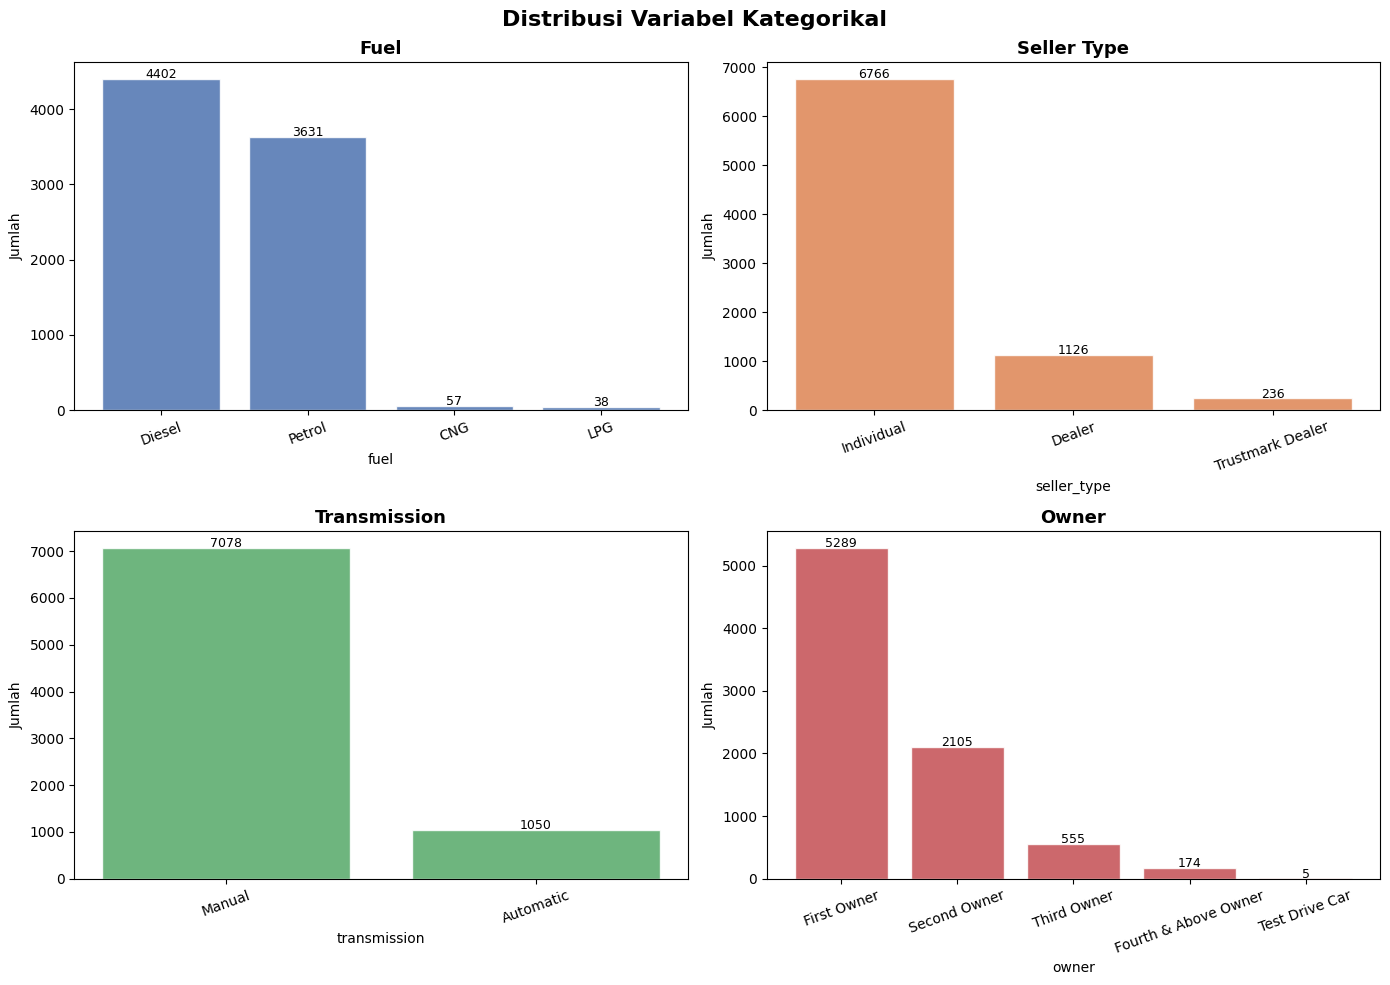

 Plot distribusi kategorikal tersimpan


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribusi Variabel Kategorikal', fontsize=16, fontweight='bold')

cat_cols = ['fuel', 'seller_type', 'transmission', 'owner']
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for ax, col, color in zip(axes.flatten(), cat_cols, colors):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(col.replace('_', ' ').title(), fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Jumlah')
    ax.tick_params(axis='x', rotation=20)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 10, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('distribusi_kategorik.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot distribusi kategorikal tersimpan')

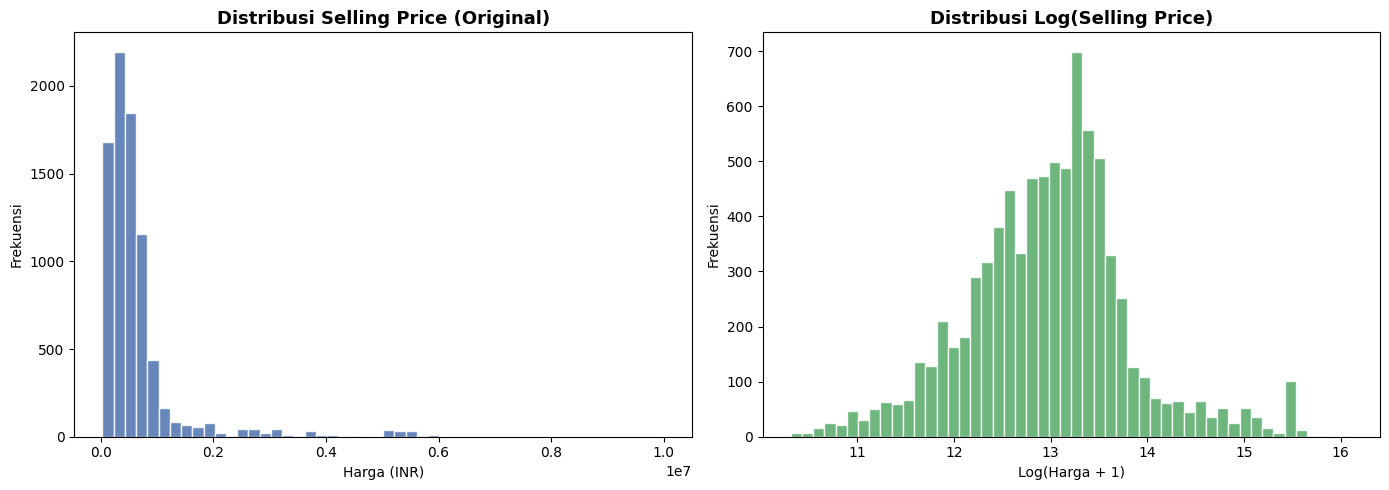

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['selling_price'], bins=50, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribusi Selling Price (Original)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Harga (INR)')
axes[0].set_ylabel('Frekuensi')

axes[1].hist(np.log1p(df['selling_price']), bins=50, color='#55A868', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribusi Log(Selling Price)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Log(Harga + 1)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('distribusi_harga.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocessing Data

In [12]:
def parse_mileage(x):
    if pd.isna(x): return np.nan
    try: return float(str(x).split()[0])
    except: return np.nan

def parse_engine(x):
    if pd.isna(x): return np.nan
    try: return float(str(x).split()[0])
    except: return np.nan

def parse_power(x):
    if pd.isna(x): return np.nan
    try: return float(str(x).split()[0])
    except: return np.nan

df['mileage'] = df['mileage'].apply(parse_mileage)
df['engine'] = df['engine'].apply(parse_engine)
df['max_power'] = df['max_power'].apply(parse_power)

df.drop(columns=['torque', 'name'], inplace=True)

print(' Parsing kolom numerik selesai')
print(f'  - mileage: {df["mileage"].dtype}')
print(f'  - engine: {df["engine"].dtype}')
print(f'  - max_power: {df["max_power"].dtype}')

 Parsing kolom numerik selesai
  - mileage: float64
  - engine: float64
  - max_power: float64


In [13]:
before = len(df)
df.dropna(inplace=True)
after = len(df)
print(f' Penghapusan missing values:')
print(f'  - Sebelum: {before} baris')
print(f'  - Sesudah: {after} baris')
print(f'  - Dihapus: {before - after} baris')

 Penghapusan missing values:
  - Sebelum: 8128 baris
  - Sesudah: 7906 baris
  - Dihapus: 222 baris


In [14]:
le_dict = {}
cat_cols = ['fuel', 'seller_type', 'transmission', 'owner']

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le
    print(f'   {col}: {list(le.classes_)} → {list(range(len(le.classes_)))}')

print('\n Label Encoding selesai')

joblib.dump(le_dict, 'label_encoders.pkl')
print(' Label encoders tersimpan di label_encoders.pkl')

   fuel: ['CNG', 'Diesel', 'LPG', 'Petrol'] → [0, 1, 2, 3]
   seller_type: ['Dealer', 'Individual', 'Trustmark Dealer'] → [0, 1, 2]
   transmission: ['Automatic', 'Manual'] → [0, 1]
   owner: ['First Owner', 'Fourth & Above Owner', 'Second Owner', 'Test Drive Car', 'Third Owner'] → [0, 1, 2, 3, 4]

 Label Encoding selesai
 Label encoders tersimpan di label_encoders.pkl


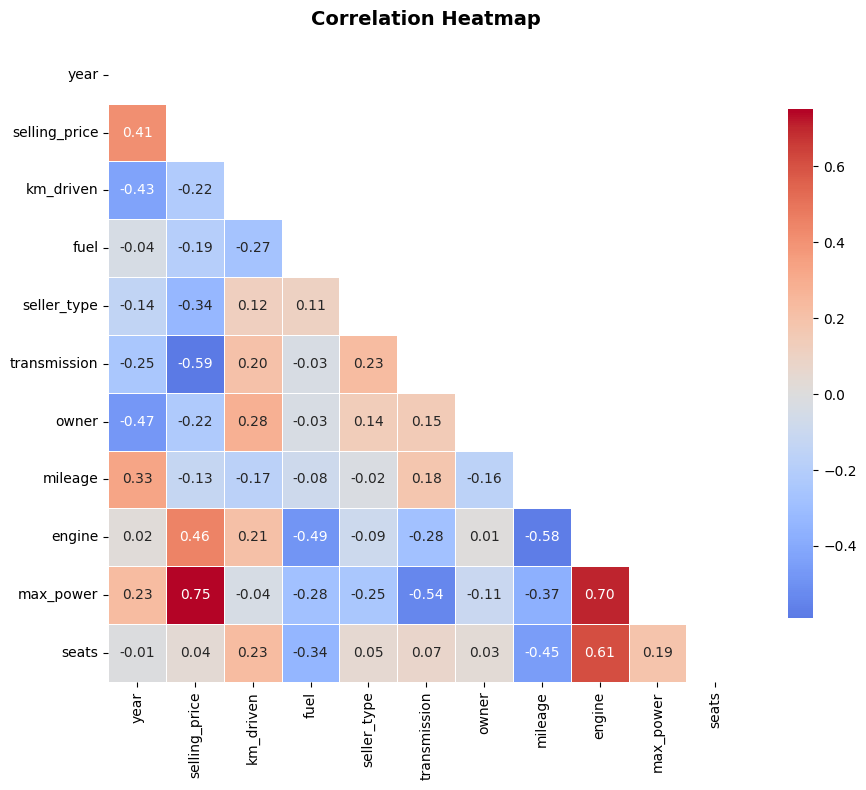

 Correlation heatmap tersimpan


In [15]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Correlation heatmap tersimpan')

## 4. Split Data Train & Test

In [16]:
X = df.drop('selling_price', axis=1)
y = df['selling_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(' Data berhasil dibagi:')
print(f'  - X_train shape: {X_train.shape}')
print(f'  - X_test shape : {X_test.shape}')
print(f'  - y_train shape: {y_train.shape}')
print(f'  - y_test shape : {y_test.shape}')
print(f'\n  Proporsi: 80% train / 20% test')
print(f'  Fitur yang digunakan: {list(X.columns)}')

 Data berhasil dibagi:
  - X_train shape: (6324, 10)
  - X_test shape : (1582, 10)
  - y_train shape: (6324,)
  - y_test shape : (1582,)

  Proporsi: 80% train / 20% test
  Fitur yang digunakan: ['year', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'mileage', 'engine', 'max_power', 'seats']


## 5. Training Model

### 5.1 XGBoost

In [17]:
print(' Training XGBoost...')

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

print(' XGBoost training selesai!')
print(f'  - n_estimators: {xgb_model.n_estimators}')
print(f'  - learning_rate: {xgb_model.learning_rate}')
print(f'  - max_depth: {xgb_model.max_depth}')

 Training XGBoost...
 XGBoost training selesai!
  - n_estimators: 300
  - learning_rate: 0.05
  - max_depth: 6


### 5.2 LightGBM

In [18]:
print(' Training LightGBM...')

lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=63,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbose=-1
)

lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)]
)

print(' LightGBM training selesai!')
print(f'  - n_estimators: {lgbm_model.n_estimators}')
print(f'  - learning_rate: {lgbm_model.learning_rate}')
print(f'  - num_leaves: {lgbm_model.num_leaves}')

 Training LightGBM...
 LightGBM training selesai!
  - n_estimators: 300
  - learning_rate: 0.05
  - num_leaves: 63


## 6. Evaluasi Model

In [19]:
def evaluate_model(y_true, y_pred, model_name):
    mae   = mean_absolute_error(y_true, y_pred)
    mse   = mean_squared_error(y_true, y_pred)
    rmse  = np.sqrt(mse)
    mape  = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2    = r2_score(y_true, y_pred)
    
    return {
        'Model': model_name,
        'MAE': round(mae, 2),
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2),
        'MAPE (%)': round(mape, 4),
        'R²': round(r2, 6)
    }

pred_xgb  = xgb_model.predict(X_test)
pred_lgbm = lgbm_model.predict(X_test)

results_xgb  = evaluate_model(y_test, pred_xgb,  'XGBoost')
results_lgbm = evaluate_model(y_test, pred_lgbm, 'LightGBM')

eval_df = pd.DataFrame([results_xgb, results_lgbm])
eval_df = eval_df.set_index('Model')

print(' HASIL EVALUASI MODEL')
print('=' * 70)
print(eval_df.to_string())
print('=' * 70)

 HASIL EVALUASI MODEL
               MAE           MSE       RMSE  MAPE (%)        R²
Model                                                          
XGBoost   64021.63  1.116540e+10  105666.45   15.2846  0.983941
LightGBM  73918.90  1.506313e+10  122731.96   17.8148  0.978335


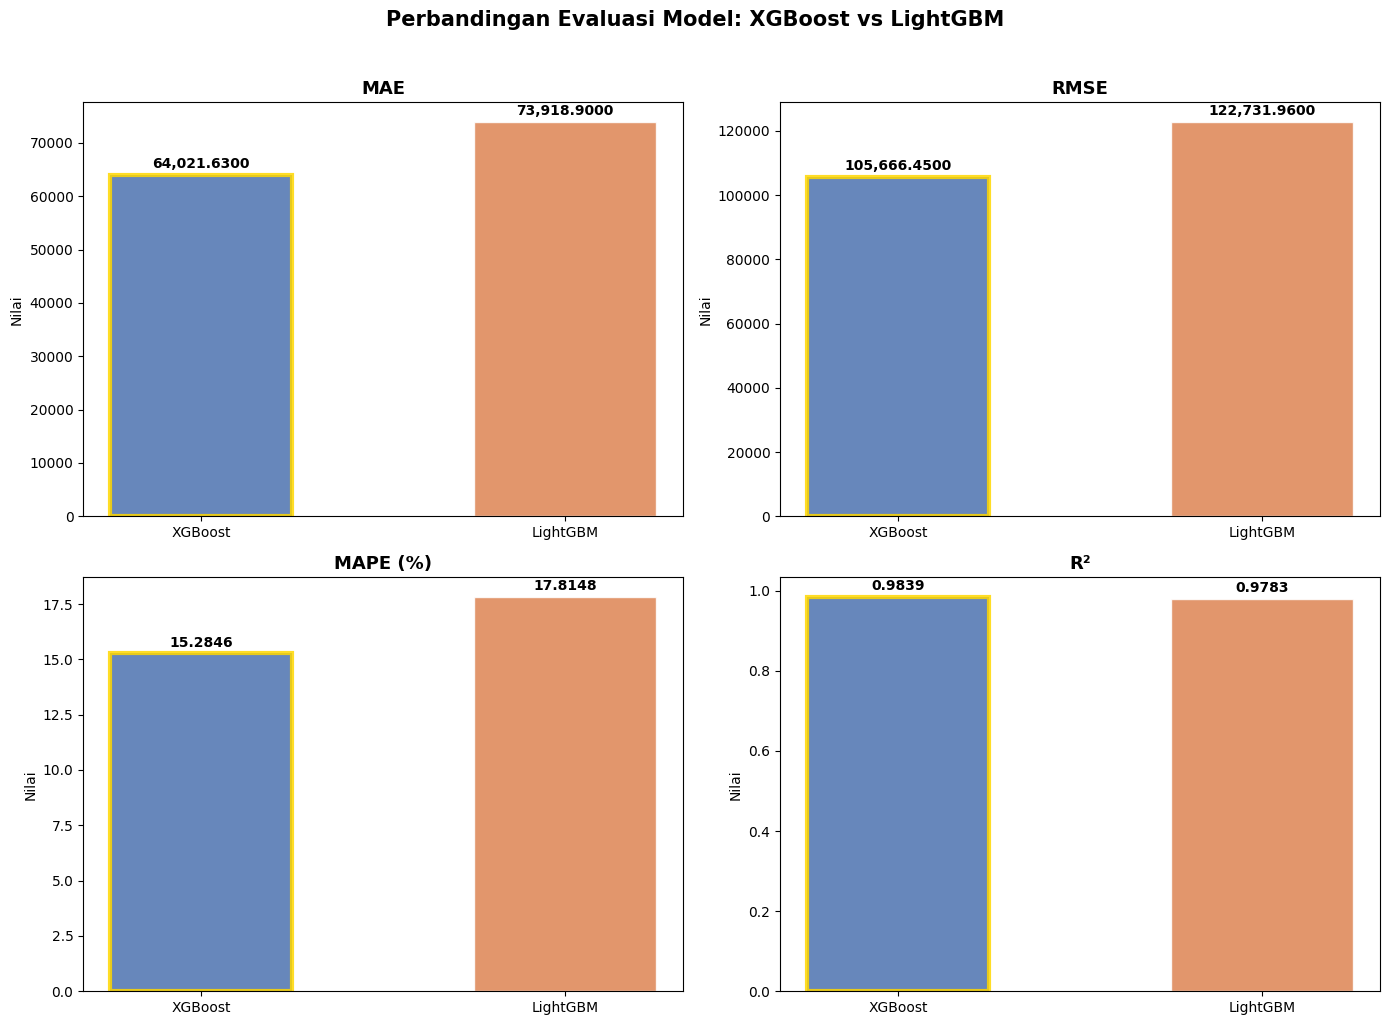

 Plot evaluasi tersimpan


In [20]:
metrics = ['MAE', 'RMSE', 'MAPE (%)', 'R²']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Perbandingan Evaluasi Model: XGBoost vs LightGBM', 
             fontsize=15, fontweight='bold', y=1.02)

colors_model = ['#4C72B0', '#DD8452']

for ax, metric in zip(axes.flatten(), metrics):
    values = [eval_df.loc['XGBoost', metric], eval_df.loc['LightGBM', metric]]
    bars = ax.bar(['XGBoost', 'LightGBM'], values, color=colors_model, 
                  alpha=0.85, edgecolor='white', width=0.5)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel('Nilai')
    
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() * 1.01,
                f'{val:,.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    if metric == 'R²':
        best_idx = values.index(max(values))
    else:
        best_idx = values.index(min(values))
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

plt.tight_layout()
plt.savefig('evaluasi_model.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot evaluasi tersimpan')

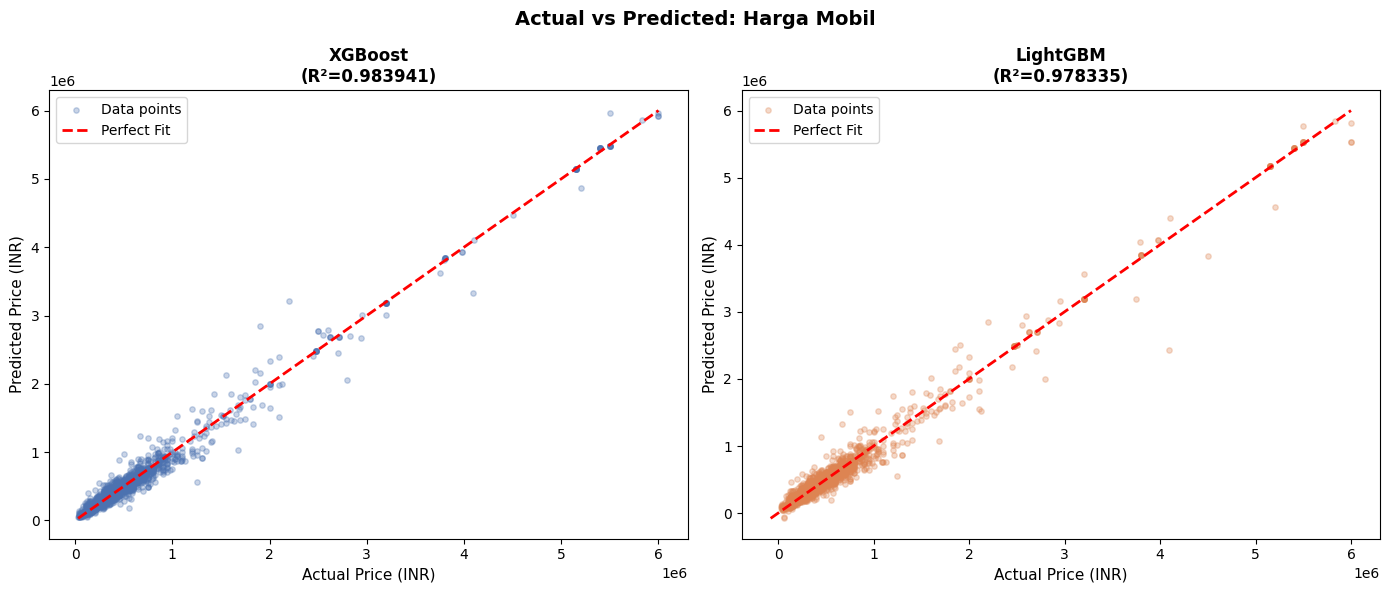

 Plot actual vs predicted tersimpan


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Actual vs Predicted: Harga Mobil', fontsize=14, fontweight='bold')

for ax, pred, name, color in zip(
    axes, [pred_xgb, pred_lgbm], ['XGBoost', 'LightGBM'], ['#4C72B0', '#DD8452']
):
    ax.scatter(y_test, pred, alpha=0.3, s=15, color=color, label='Data points')
    min_val = min(y_test.min(), pred.min())
    max_val = max(y_test.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')
    ax.set_xlabel('Actual Price (INR)', fontsize=11)
    ax.set_ylabel('Predicted Price (INR)', fontsize=11)
    ax.set_title(f'{name}\n(R²={eval_df.loc[name,"R²"]})', fontsize=12, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot actual vs predicted tersimpan')

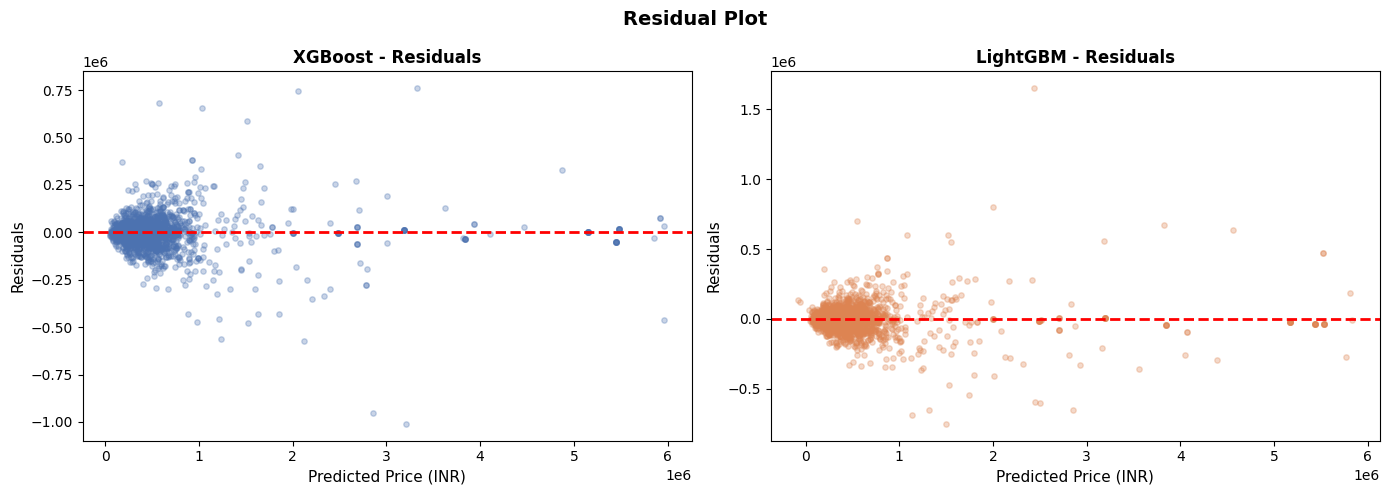

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Residual Plot', fontsize=14, fontweight='bold')

for ax, pred, name, color in zip(
    axes, [pred_xgb, pred_lgbm], ['XGBoost', 'LightGBM'], ['#4C72B0', '#DD8452']
):
    residuals = y_test.values - pred
    ax.scatter(pred, residuals, alpha=0.3, s=15, color=color)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel('Predicted Price (INR)', fontsize=11)
    ax.set_ylabel('Residuals', fontsize=11)
    ax.set_title(f'{name} - Residuals', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('residual_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Importance

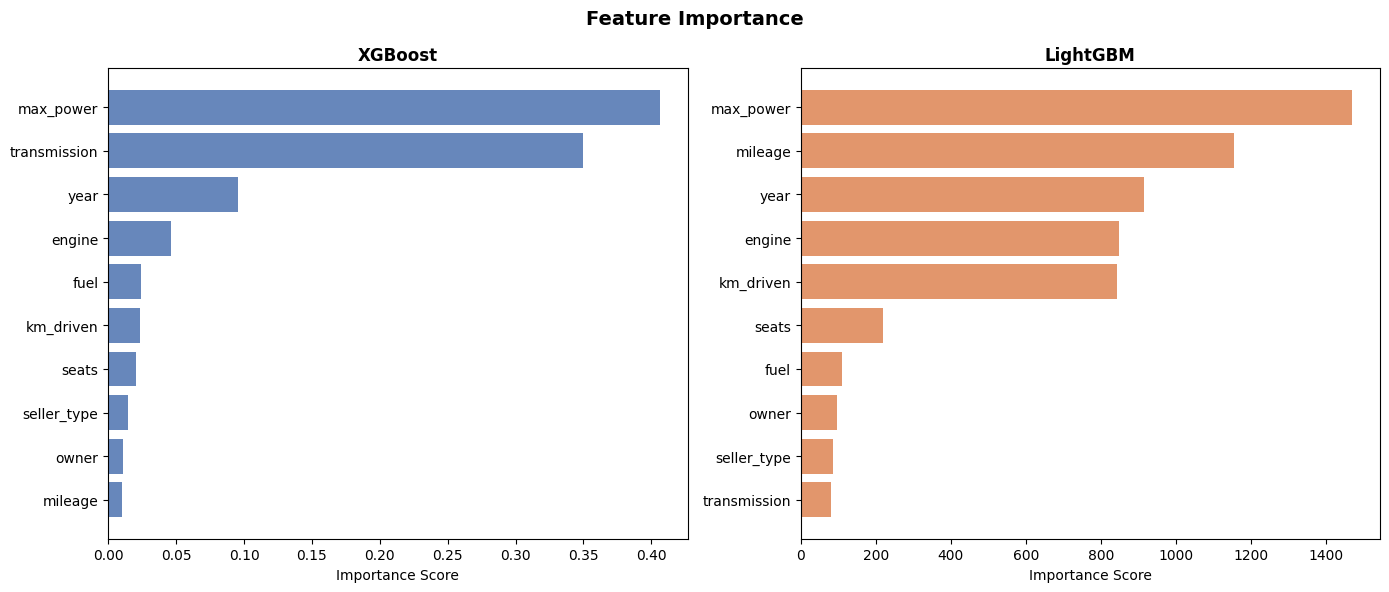

 Plot feature importance tersimpan


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Feature Importance', fontsize=14, fontweight='bold')

xgb_imp = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=True)
axes[0].barh(xgb_imp.index, xgb_imp.values, color='#4C72B0', alpha=0.85)
axes[0].set_title('XGBoost', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance Score')

lgbm_imp = pd.Series(lgbm_model.feature_importances_, index=X.columns).sort_values(ascending=True)
axes[1].barh(lgbm_imp.index, lgbm_imp.values, color='#DD8452', alpha=0.85)
axes[1].set_title('LightGBM', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Plot feature importance tersimpan')

## 8. Kesimpulan & Simpan Model Terbaik

In [24]:
r2_xgb  = eval_df.loc['XGBoost', 'R²']
r2_lgbm = eval_df.loc['LightGBM', 'R²']

if r2_xgb >= r2_lgbm:
    best_model = xgb_model
    best_name  = 'XGBoost'
else:
    best_model = lgbm_model
    best_name  = 'LightGBM'

print(f' MODEL TERBAIK: {best_name}')
print(f'   MAE      : {eval_df.loc[best_name, "MAE"]:>15,.2f} INR')
print(f'   MSE      : {eval_df.loc[best_name, "MSE"]:>15,.2f}')
print(f'   RMSE     : {eval_df.loc[best_name, "RMSE"]:>15,.2f} INR')
print(f'   MAPE     : {eval_df.loc[best_name, "MAPE (%)"]:.4f} %')
print(f'   R²       : {eval_df.loc[best_name, "R²"]:.6f}')

joblib.dump(best_model, 'best_model.pkl')
print(f'\n Model terbaik ({best_name}) tersimpan di best_model.pkl')

joblib.dump(xgb_model, 'xgb_model.pkl')
joblib.dump(lgbm_model, 'lgbm_model.pkl')
print(' xgb_model.pkl dan lgbm_model.pkl tersimpan')

metadata = {
    'best_model': best_name,
    'features': list(X.columns),
    'label_encoders_classes': {col: list(le.classes_) for col, le in le_dict.items()},
    'metrics': {
        'XGBoost': results_xgb,
        'LightGBM': results_lgbm
    }
}
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(' model_metadata.json tersimpan')

 MODEL TERBAIK: XGBoost
   MAE      :       64,021.63 INR
   MSE      : 11,165,399,040.00
   RMSE     :      105,666.45 INR
   MAPE     : 15.2846 %
   R²       : 0.983941

 Model terbaik (XGBoost) tersimpan di best_model.pkl
 xgb_model.pkl dan lgbm_model.pkl tersimpan
 model_metadata.json tersimpan


In [25]:
print('\n' + '='*60)
print(' RINGKASAN AKHIR')
print('='*60)
print(f'Dataset      : Car Details v3 ({df.shape[0]} baris × {df.shape[1]} kolom)')
print(f'Split        : 80% train / 20% test')
print(f'Model        : XGBoost, LightGBM')
print(f'Evaluasi     : MAE, MSE, RMSE, MAPE, R²')
print(f'Model Terbaik: {best_name} (R² = {eval_df.loc[best_name, "R²"]})')
print('='*60)
print('\nFile yang dihasilkan:')
print('   best_model.pkl        → Model terbaik untuk deployment')
print('   xgb_model.pkl         → Model XGBoost')
print('   lgbm_model.pkl        → Model LightGBM')
print('   label_encoders.pkl    → Label encoder untuk fitur kategorikal')
print('   model_metadata.json   → Metadata model & evaluasi')
print('    *.png                 → Plot visualisasi')


 RINGKASAN AKHIR
Dataset      : Car Details v3 (7906 baris × 11 kolom)
Split        : 80% train / 20% test
Model        : XGBoost, LightGBM
Evaluasi     : MAE, MSE, RMSE, MAPE, R²
Model Terbaik: XGBoost (R² = 0.983941)

File yang dihasilkan:
   best_model.pkl        → Model terbaik untuk deployment
   xgb_model.pkl         → Model XGBoost
   lgbm_model.pkl        → Model LightGBM
   label_encoders.pkl    → Label encoder untuk fitur kategorikal
   model_metadata.json   → Metadata model & evaluasi
    *.png                 → Plot visualisasi
